# KMeans= Initialize → Assign → Update → Repeat

In [115]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load Datasets

In [116]:
df = pd.read_csv("https://gist.githubusercontent.com/pravalliyaram/5c05f43d2351249927b8a3f3cc3e5ecf/raw/8bd6144a87988213693754baaa13fb204933282d/Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [118]:
X=df[['Annual Income (k$)', 'Spending Score (1-100)']]

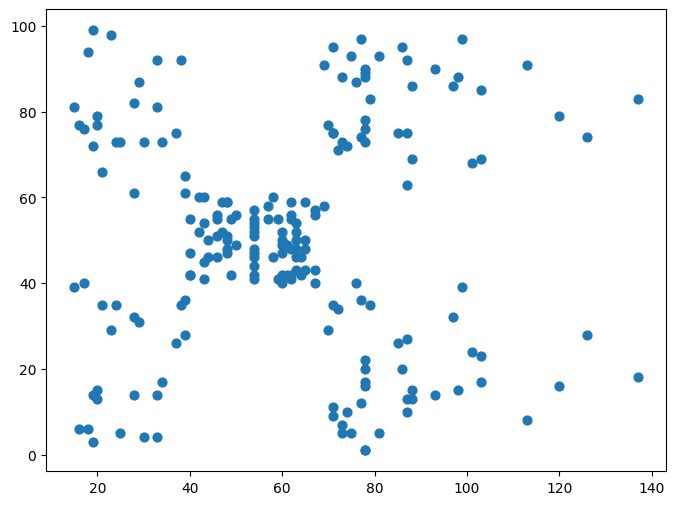

In [119]:
plt.figure(figsize=(8,6))
plt.scatter(X.iloc[:,0], X.iloc[:,1], s=40)

In [120]:
scaler= StandardScaler()
X_scaled= scaler.fit_transform(X)

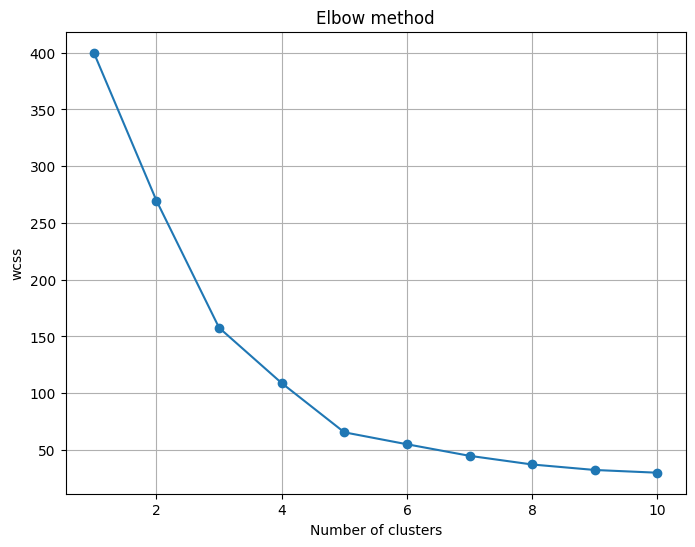

In [121]:
wcss= []
for i in range(1,11):
  model= KMeans(n_clusters= i, n_init=10, random_state=42)
  model.fit(X_scaled)
  wcss.append(model.inertia_)

plt.figure(figsize=(8,6))
plt.plot(range(1,11), wcss, marker= 'o')
plt.title('Elbow method')
plt.ylabel('wcss')
plt.xlabel('Number of clusters')
plt.grid(True)
plt.show()

In [122]:
# We take k=5

model= KMeans(n_clusters=5, random_state=42, n_init=10)
model.fit(X_scaled)

centers= model.cluster_centers_ #Centroid
label= model.labels_ #Labels

df['Cluster']= label

In [123]:
print(f'Centroid: \n{centers}\n')
print(f'Labels: {label}')

Centroid: 
[[-0.20091257 -0.02645617]
 [ 0.99158305  1.23950275]
 [-1.32954532  1.13217788]
 [ 1.05500302 -1.28443907]
 [-1.30751869 -1.13696536]]

Labels: [4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 4 2 4 0 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 0 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


In [124]:
df.groupby('Cluster')['Age'].describe()

,count,mean,std,min,25%,50%,75%,max
Cluster,,,,,,,,
0,81.0,42.716049,16.447822,18.0,27.00,46.0,54.00,70.0
1,39.0,32.692308,3.728650,27.0,30.00,32.0,35.50,40.0
2,22.0,25.272727,5.257030,18.0,21.25,23.5,29.75,35.0
3,35.0,41.114286,11.341676,19.0,34.00,42.0,47.50,59.0
4,23.0,45.217391,13.228607,19.0,35.50,46.0,53.50,67.0


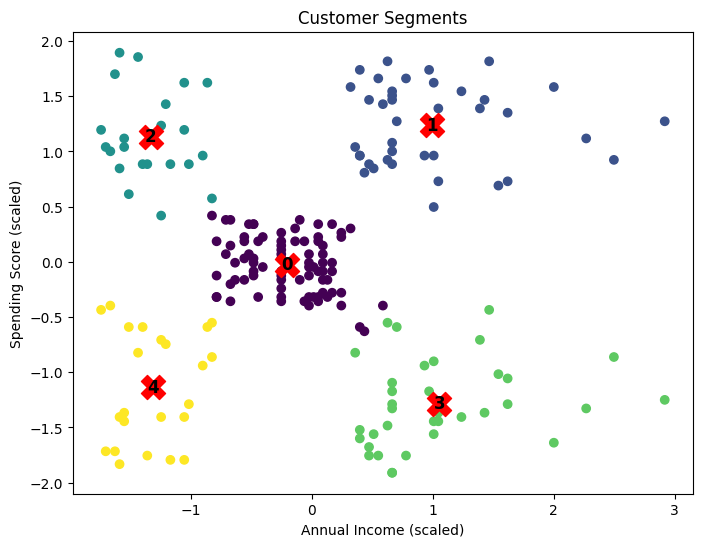

In [125]:
plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=label, cmap='viridis')
# plot centroids
plt.scatter(centers[:,0], centers[:,1], s=300, c='red', marker='X')

# add cluster labels
for i, center in enumerate(centers):
    plt.text(center[0], center[1], str(i),
             fontsize=12, fontweight='bold',
             color='black',
             ha='center', va='center')

plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.title("Customer Segments")
plt.show()

In [126]:
gender_dist= pd.crosstab(df['Cluster'], df['Gender'], normalize= 'index')*100
gender_dist

Gender,Female,Male
Cluster,,
0,59.259259,40.740741
1,53.846154,46.153846
2,59.090909,40.909091
3,45.714286,54.285714
4,60.869565,39.130435


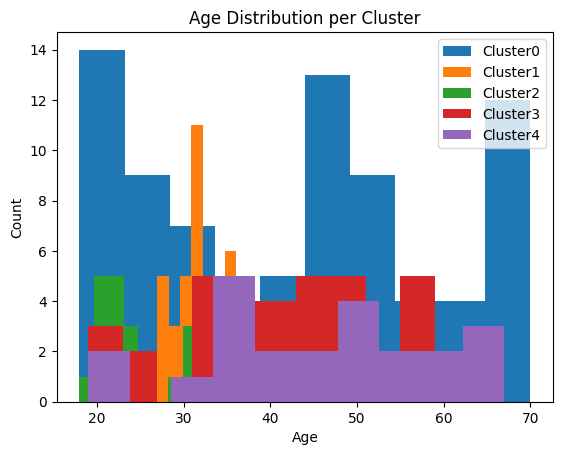

In [127]:
for c in sorted(df['Cluster'].unique()):
  plt.hist(df[df['Cluster']==c]['Age'], alpha=1, label= f'Cluster{c}')

plt.legend()
plt.title("Age Distribution per Cluster")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

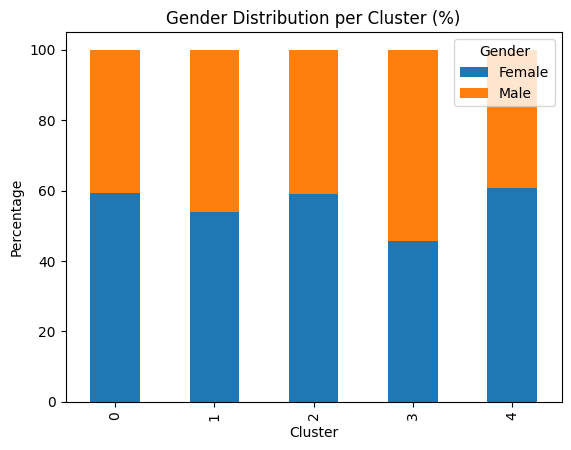

In [128]:
gender_dist.plot(kind='bar', stacked= True)
plt.title("Gender Distribution per Cluster (%)")
plt.ylabel("Percentage")
plt.show()

# Business Interpretion

🟣 Cluster 2: Young-heavy cluster

Mostly age 18–30
High spending score
👉 Interpretation:

Trend-driven, impulsive buyers

🔵 Cluster 1: Older high-income group

Age 40–60
High income but variable spending
👉 Interpretation:

Conservative but premium-targetable customers

🟢 Cluster 0: Gender skewed cluster

e.g., more female customers in high spending cluster
👉 Interpretation:

Product-category targeting opportunity